In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np
import sklearn as sk
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc


In [3]:
# Create a flow from directory for training data
train_generator = tf.keras.preprocessing.image_dataset_from_directory(
    r'C:\Users\haide\Alzheimer_s Dataset\train',  
    validation_split=0.2,
    subset='training',
    seed=1200,
    image_size=(224, 224), 
    batch_size=32,
    shuffle=True,
    labels='inferred',
    label_mode ='categorical'
)

# Create a flow from directory for validation data
val_generator = tf.keras.preprocessing.image_dataset_from_directory(
    r'C:\Users\haide\Alzheimer_s Dataset\test',  # Corrected closing quotation mark
    validation_split=0.2,
    subset='validation',
    seed=1377,
    image_size=(224, 224),
    batch_size=32,
    shuffle=True,
    labels='inferred',
    label_mode='categorical'
)


Found 5121 files belonging to 4 classes.
Using 4097 files for training.
Found 1279 files belonging to 4 classes.
Using 255 files for validation.


In [4]:
class_names = ['MildDementia', 'ModerateDementia', 'NonDementia', 'VeryMildDementia']
train_generator.class_names = class_names
val_generator.class_names = class_names

num_classes = len(class_names)

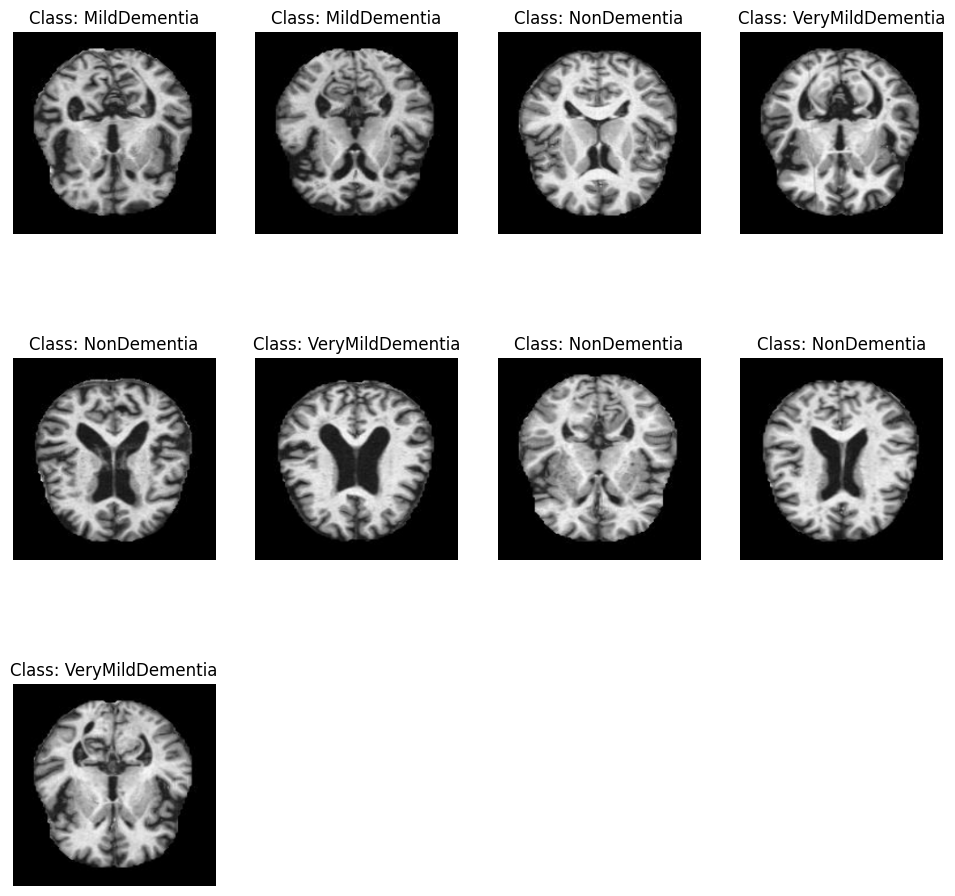

In [5]:
plt.figure(figsize=(12, 12))  # Adjusted figure size for a different layout
for images, labels in train_generator.take(1):
    for i in range(9):  # Loop to plot 9 images
        ax = plt.subplot(3, 4, i + 1)  # Changed layout to 3x4
        plt.imshow(images[i].numpy().astype("uint8"))
        label_scalar = labels[i].numpy().argmax()  # Convert label Tensor to a scalar integer
        label_name = train_generator.class_names[label_scalar]
        plt.title(f"Class: {label_name}")  
        plt.axis("off")



In [6]:
import os


train_dir = r'C:\Users\haide\Alzheimer_s Dataset\train'

# Dictionary to hold the count of images for each class
class_counts = {
    'MildDemented': 717,
    'ModerateDemented': 52,
    'NonDemented': 2560,
    'VeryMildDemented': 1792
}

# Ensure class_names are in the same order as they are in train_generator.class_names
class_names_in_order = ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']

# Iterate over each folder (which represents a class) in the training directory
for class_folder in os.listdir(train_dir):
    # Construct the full path to the class folder
    class_folder_path = os.path.join(train_dir, class_folder)
    
    # Check if it's a directory
    if os.path.isdir(class_folder_path):
        # Count the number of image files in the class directory
        class_counts[class_folder] = len(os.listdir(class_folder_path))

# Print the counts for each class
for class_name, count in class_counts.items():
    print(f'Class {class_name}: {count} images')

Class MildDemented: 717 images
Class ModerateDemented: 52 images
Class NonDemented: 2560 images
Class VeryMildDemented: 1792 images


In [7]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Flatten, Dropout, Conv2D, MaxPooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras import Sequential
from tensorflow.keras.regularizers import l1, l2, l1_l2


reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-5, verbose=1)

def create_custom_cnn(input_shape, num_classes):
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape, kernel_regularizer=l2(0.001)),
        MaxPooling2D((2, 2)),
        Dense(256, activation='relu'),
        Conv2D(64, (3, 3), activation='relu', kernel_regularizer=l2(0.010)),
        MaxPooling2D((2, 2)),
        Dense(256, activation='relu'),
        Conv2D(128, (3, 3), activation='relu'),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.4),
        Dense(4, activation='softmax')
        
    ])
    return model

# Now, let's define the ResNet50-based model
def create_resnet50_model(input_shape, num_classes):
    # Load ResNet50 pre-trained on ImageNet without the top layer (fully connected layers)
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)

    # Freeze the layers of the base model
    for layer in base_model.layers:
        layer.trainable = False

    # Create the custom layers on top of ResNet50
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)  # Dropout rate increased to 0.5 for regularization
    predictions = Dense(num_classes, activation='softmax')(x)

    # This is the model we will train
    model = Model(inputs=base_model.input, outputs=predictions)
    
    return model

# Callback to reduce learning rate when a metric has stopped improving
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-5, verbose=1)

# Prepare the custom CNN model
input_shape = (224, 224, 3)
num_classes = 4  # Replace with the actual number of classes
custom_cnn_model = create_custom_cnn(input_shape, num_classes)
custom_cnn_model.compile(optimizer=Adam(learning_rate=0.001), 
                         loss='categorical_crossentropy', 
                         metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
    ])

# Prepare the ResNet50 model
resnet50_model = create_resnet50_model(input_shape, num_classes)
resnet50_model.compile(optimizer=Adam(learning_rate=0.001), 
                       loss='categorical_crossentropy', 
                       metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
    ])


In [8]:
 history = custom_cnn_model.fit(
    train_generator,
    validation_data =val_generator,
    epochs=10,# formerly 20
     callbacks=[reduce_lr]
)

Epoch 1/10
129/129 [==============================] - 23s 131ms/step - loss: 6.1625 - accuracy: 0.4796 - auc: 0.7656 - precision: 0.5321 - recall: 0.2465 - val_loss: 1.6002 - val_accuracy: 0.3451 - val_auc: 0.7185 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - lr: 0.0010
Epoch 2/10
129/129 [==============================] - 16s 122ms/step - loss: 1.4459 - accuracy: 0.5033 - auc: 0.8004 - precision: 0.5837 - recall: 0.2927 - val_loss: 1.4816 - val_accuracy: 0.4980 - val_auc: 0.7721 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - lr: 0.0010
Epoch 3/10
129/129 [==============================] - 18s 137ms/step - loss: 1.3074 - accuracy: 0.5431 - auc: 0.8251 - precision: 0.6359 - recall: 0.3385 - val_loss: 1.3854 - val_accuracy: 0.5255 - val_auc: 0.7874 - val_precision: 0.5986 - val_recall: 0.3333 - lr: 0.0010
Epoch 4/10
129/129 [==============================] - 17s 132ms/step - loss: 1.2058 - accuracy: 0.5731 - auc: 0.8455 - precision: 0.6554 - recall: 0.3891 - val_loss: 1.

In [15]:
# Train the ResNet50 model
history_resnet50 = resnet50_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[reduce_lr]
)

Epoch 1/20
129/129 [==============================] - 14s 90ms/step - loss: 1.0846 - accuracy: 0.5070 - auc: 0.7959 - precision: 0.5599 - recall: 0.3754 - val_loss: 0.9147 - val_accuracy: 0.5615 - val_auc: 0.8397 - val_precision: 0.6485 - val_recall: 0.4072 - lr: 0.0010
Epoch 2/20
129/129 [==============================] - 11s 84ms/step - loss: 0.9389 - accuracy: 0.5536 - auc: 0.8321 - precision: 0.6480 - recall: 0.3564 - val_loss: 0.8904 - val_accuracy: 0.5547 - val_auc: 0.8438 - val_precision: 0.6401 - val_recall: 0.3838 - lr: 0.0010
Epoch 3/20
129/129 [==============================] - 11s 85ms/step - loss: 0.8942 - accuracy: 0.5587 - auc: 0.8449 - precision: 0.6713 - recall: 0.3788 - val_loss: 0.8553 - val_accuracy: 0.5713 - val_auc: 0.8558 - val_precision: 0.7172 - val_recall: 0.3838 - lr: 0.0010
Epoch 4/20
129/129 [==============================] - 11s 85ms/step - loss: 0.8828 - accuracy: 0.5765 - auc: 0.8501 - precision: 0.6873 - recall: 0.3815 - val_loss: 0.8437 - val_accuracy:

In [10]:
test_data_generator = tf.keras.preprocessing.image_dataset_from_directory(
    directory=r'C:\Users\haide\Alzheimer_s Dataset\test',  # Path to test data
    label_mode='categorical', 
    image_size=(224, 224),     
    batch_size=15,           
    shuffle=True             
)

# Evaluate the model on the test set
evaluation_results = custom_cnn_model.evaluate(test_data_generator)


# Print the results
print("Loss:", evaluation_results[0])
print("Accuracy:", evaluation_results[1])
print("AUC:", evaluation_results[2])
print("Precision:", evaluation_results[3])
print("Recall:", evaluation_results[4])


Found 1279 files belonging to 4 classes.
86/86 [==============================] - 3s 29ms/step - loss: 2.8614 - accuracy: 0.5340 - auc: 0.7769 - precision: 0.5349 - recall: 0.5278
Loss: 2.86137318611145
Accuracy: 0.5340109467506409
AUC: 0.7769214510917664
Precision: 0.5348653197288513
Recall: 0.5277560353279114


In [13]:
custom_cnn_model.save('my_model')

INFO:tensorflow:Assets written to: my_model\assets


INFO:tensorflow:Assets written to: my_model\assets


In [14]:
precision = history.history['precision'][-1]
recall = history.history['recall'][-1]
f1_score = 2 * (precision * recall) / (precision + recall)
print(f"F1 Score: {f1_score}")

F1 Score: 0.9322807489693011


In [12]:
#Here is a confusion matrix which shows how well the model is classifying each category:
from sklearn.metrics import confusion_matrix
import pandas as pd
import seaborn as sns


def plot_confusion_matrix(model, test_data_generator):
    # Predictions and true labels
    predictions = model.predict(test_data_generator)
    y_pred = np.argmax(predictions, axis=1)
    y_true = np.concatenate([y for x, y in test_data_generator], axis=0)
    y_true = np.argmax(y_true, axis=1)

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    cm_df = pd.DataFrame(cm,
                         index = test_data_generator.class_names, 
                         columns = test_data_generator.class_names)

    # Plotting
    plt.figure(figsize=(8,6))
    sns.heatmap(cm_df, annot=True, fmt='g', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

86/86 [==============================] - 2s 23ms/step


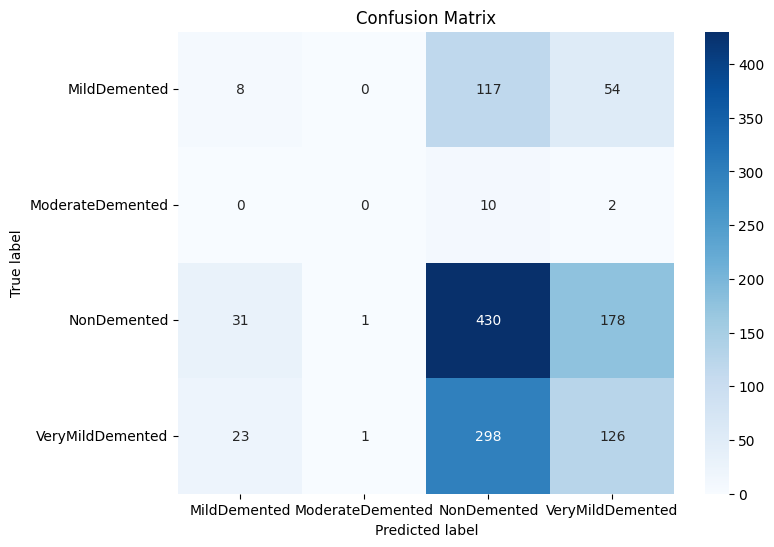

In [13]:
plot_confusion_matrix(custom_cnn_model, test_data_generator)

86/86 [==============================] - 3s 21ms/step


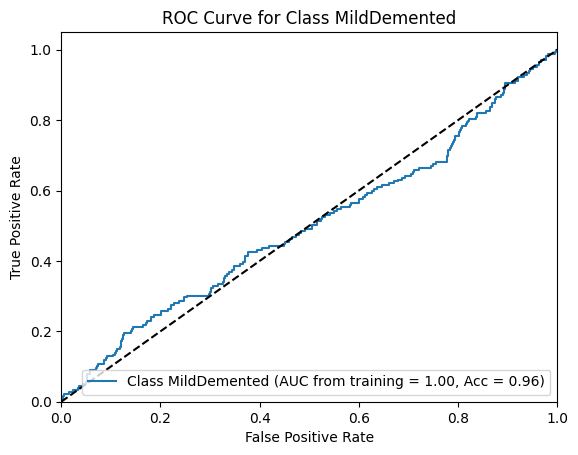

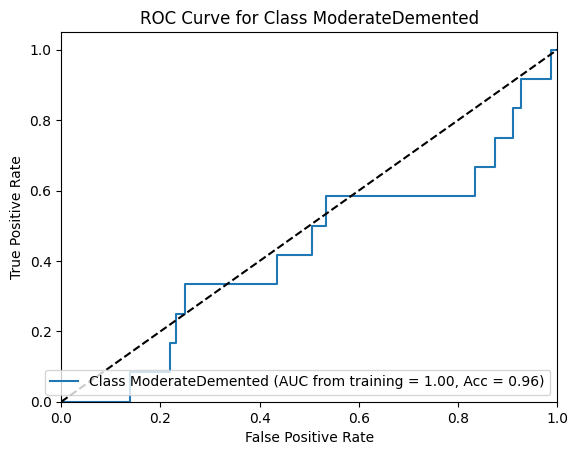

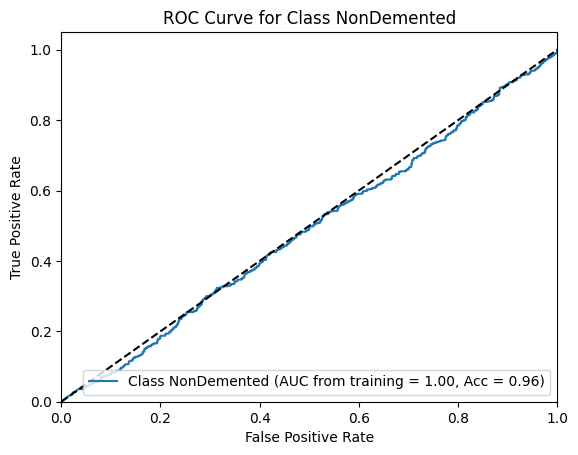

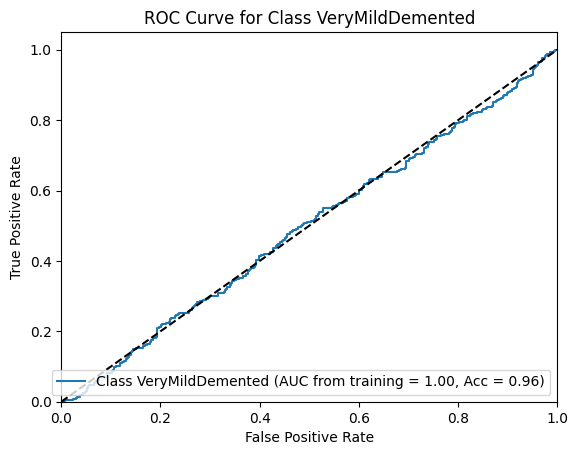

In [16]:
def plot_roc_curves_with_history(history, test_data_generator, num_classes):
    # Extract metrics from history
    training_auc = history.history['auc'][-1]  # Assuming you have 'auc' metric in your model
    training_acc = history.history['accuracy'][-1]  # Example: accessing accuracy

    # Make predictions on the test data
    predictions = custom_cnn_model.predict(test_data_generator)
    y_true = np.concatenate([y for x, y in test_data_generator], axis=0)

    # Compute ROC curves and AUC for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(num_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true[:, i], predictions[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Plot ROC curves
    for i in range(num_classes):
        plt.figure()
        plt.plot(fpr[i], tpr[i], label='Class {0} (AUC from training = {1:0.2f}, Acc = {2:0.2f})'.format(
            test_data_generator.class_names[i], training_auc, training_acc))
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve for Class {0}'.format(test_data_generator.class_names[i]))
        plt.legend(loc="lower right")
        plt.show()

# Call the function with appropriate arguments
plot_roc_curves_with_history(history, test_data_generator, num_classes)


In [ ]:
def plot_training_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs = range(len(acc))

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'r', label='Training accuracy')
    plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
    plt.title('Training and validation accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'r', label='Training Loss')
    plt.plot(epochs, val_loss, 'b', label='Validation Loss')
    plt.title('Training and validation loss')
    plt.legend()

    plt.show()

In [ ]:
plot_training_history(history)

In [11]:
def display_sample_predictions(model, test_data_generator, num_samples=10):
    plt.figure(figsize=(12, 12))
    seen_images = []
    seen_labels = []

    for images, labels in test_data_generator:
        for i in range(len(images)):
            if len(seen_images) >= num_samples:
                break
            seen_images.append(images[i])
            seen_labels.append(labels[i])
        if len(seen_images) >= num_samples:
            break

    for i in range(num_samples):
        img = seen_images[i]
        actual_label = test_data_generator.class_names[np.argmax(seen_labels[i])]
        predicted_label = test_data_generator.class_names[np.argmax(model.predict(np.expand_dims(img, axis=0))[0])]
        plt.subplot(5, 2, i + 1)
        plt.imshow(img.numpy().astype("uint8"))
        plt.title(f"Actual: {actual_label}, Predicted: {predicted_label}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


1/1 [==============================] - 0s 36ms/step


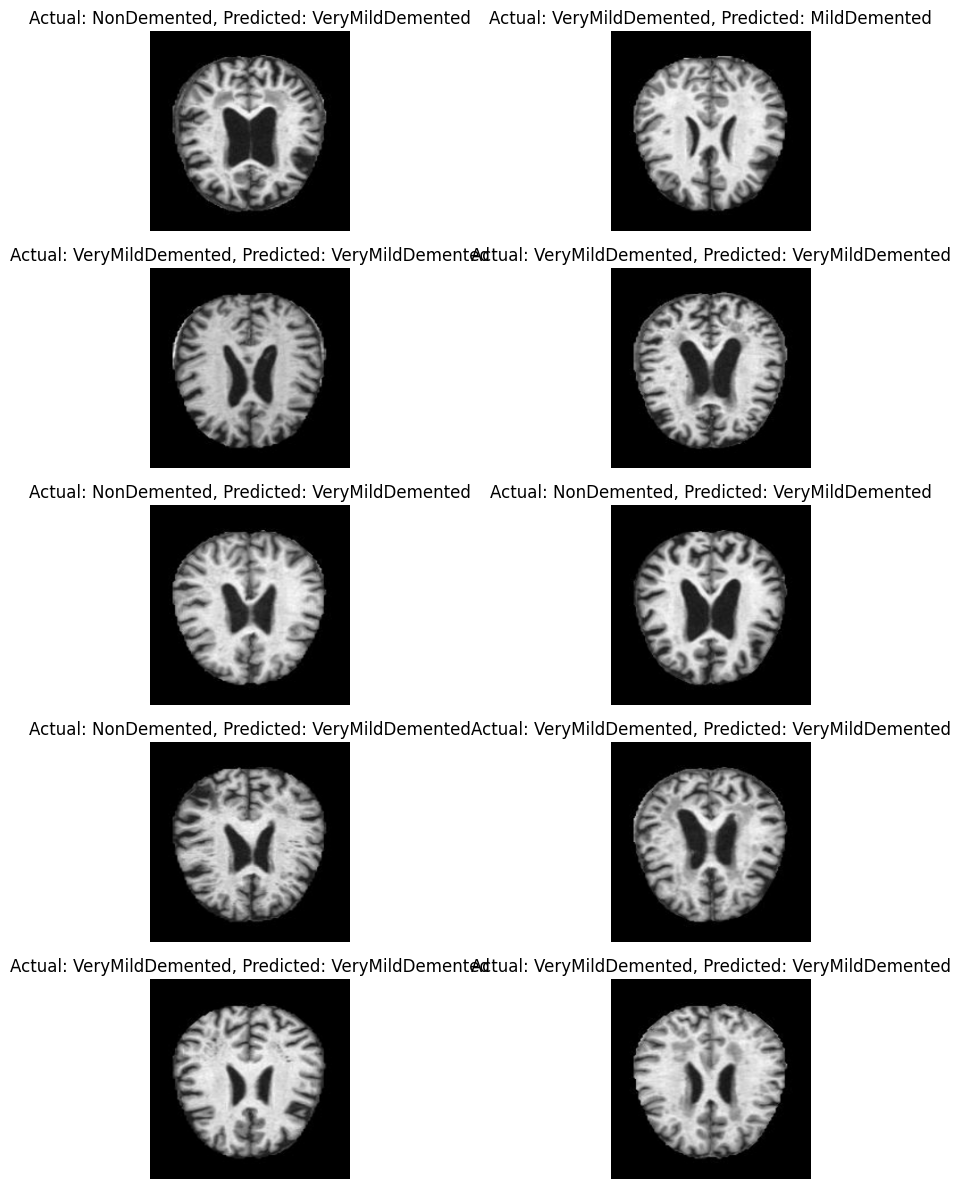

In [12]:
display_sample_predictions(custom_cnn_model, test_data_generator)